# 랜덤 포레스트 회귀
랜덤 포레스트 회귀는 여러 개의 결정 트리 회귀 모델을 만들고, 그 예측 값들의 평균을 내는 회귀 모델입니다.

<img src="https://media.geeksforgeeks.org/wp-content/uploads/20260313111708730410/random-forest-regression22.jpg" style="width: 240px">

## 특징
결정 트리 하나는 굉장히 민감하여 데이터가 조금만 바뀌어도 트리 구조가 많이 바뀔 수 있고, 너무 깊게 만들면 과적합이 될 수 있습니다.

### 데이터 샘플링
이에 따라 트리를 여러개 만들어둔 방식인 **랜덤 포레스트**를 사용하여 **부트스트랩 샘플링**(뽑은걸 다시 뽑기가능, 복원 추출)방식으로 데이터를 추출하여 학습시킵니다.

### 특성 선택
각 분기에서 사용할 특성도 일부만 랜덤하게 고려합니다. 특성이 `A`~`G`까지 있다고 한다면, 어떤 트리는 `[A, C, F]`를 중심으로 쓰고, 어떤 트리는 `[B, C, F]`를 중심으로 사용할 수 있습니다.

# 장단점
선형회귀와 비교해보면 선형 회귀는 직선/평면 형태로 표현할 수 있지만 랜덤 포레스트는 비선형적인 관계를 잘 잡을 수 있습니다.

예를 들면 무게와의 증가 비율은 선형 회귀도 잘 잡을 수 있지만 일정 구간부터 증가폭이 낮아진다던가 반대로 안좋아지는 경우는 랜덤포레스트가 더 잘 잡을 수 있습니다.
### 장점
- 비선형 관계를 잘 잡음
- 이상치에 비교적 강함
- 스케일링이 거의 필요 없음
- 과적합이 결정트리 하나보다 훨씬 적음
- 변수 중요도를 볼 수 있음
### 단점
- 계수 해석이 쉽지 않음
- 내부가 복잡해서 설명력이 떨어짐
- 데이터 범위 밖의 예측이 약함
- 트리가 많으면 계산량이 늘어남

In [1]:
from ucimlrepo import fetch_ucirepo
import pandas as pd

data = fetch_ucirepo(id=9)

df = pd.concat((
  data.data.features,
  data.data.targets
), axis=1)
df

,displacement,cylinders,horsepower,weight,acceleration,model_year,origin,mpg
0,307.0,8,130.0,3504,12.0,70,1,18.0
1,350.0,8,165.0,3693,11.5,70,1,15.0
2,318.0,8,150.0,3436,11.0,70,1,18.0
3,304.0,8,150.0,3433,12.0,70,1,16.0
4,302.0,8,140.0,3449,10.5,70,1,17.0
...,...,...,...,...,...,...,...,...
393,140.0,4,86.0,2790,15.6,82,1,27.0
394,97.0,4,52.0,2130,24.6,82,2,44.0
395,135.0,4,84.0,2295,11.6,82,1,32.0
396,120.0,4,79.0,2625,18.6,82,1,28.0


In [2]:
df = df.dropna(axis=0)
X = df.drop("mpg", axis=1)
y = df["mpg"]

In [3]:
X = pd.get_dummies(X, columns=["origin"])
X.columns

Index(['displacement', 'cylinders', 'horsepower', 'weight', 'acceleration',
       'model_year', 'origin_1', 'origin_2', 'origin_3'],
      dtype='str')

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
  X, y,
  test_size=0.2,
  random_state=42
)

In [5]:
from sklearn.ensemble import RandomForestRegressor
from sklearn import set_config

set_config(display="text")

rf_model = RandomForestRegressor(
  n_estimators=100, # 결정 트리 100개를 만든다는 의미
  random_state=42
)

# 표준화 없이 바로 모델링 하기
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [6]:
pred = rf_model.predict(X_test)

result = pd.DataFrame({
  "실제": y_test,
  "예측": pred,
  "오차": abs(y_test-pred)
})

result.T

,79,276,248,56,393,205,43,235,152,117,...,5,46,85,241,111,366,83,115,3,18
실제,26.00,21.600,36.100,26.000,27.000,28.000,13.000,26.00,19.00,29.000,...,15.000,22.000,13.000,22.000,18.00,17.600,28.00,15.0,16.00,27.000
예측,26.15,22.229,34.406,30.439,26.674,28.166,12.995,28.48,19.59,30.935,...,13.695,23.635,13.255,22.438,27.14,24.129,26.55,13.7,16.84,26.915
오차,0.15,0.629,1.694,4.439,0.326,0.166,0.005,2.48,0.59,1.935,...,1.305,1.635,0.255,0.438,9.14,6.529,1.45,1.3,0.84,0.085


In [7]:
train_score = rf_model.score(X_train, y_train)
test_score = rf_model.score(X_test, y_test)

print("train R2:", train_score)
print("test R2:", test_score)

train R2: 0.9810297014704484
test R2: 0.8858903470374668


# 어느정도 과적합 되어있는 상태
- train R2: 0.9810297014704484
- test R2: 0.8858903470374668

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("랜덤 포레스트 R2:", r2)
print("랜덤 포레스트 MAE:", mae)
print("랜덤 포레스트 RMSE:", rmse)

print("""
릿지 회귀 R2:  0.8104121264748629
릿지 회귀 MAE:  2.456596505018637
릿지 회귀 RMSE:  3.257306515093934
      
선형 회귀 R2:  0.8122496423097463
선형 회귀 MAE:  2.4619996980661494
선형 회귀 RMSE:  3.2561140968474023
""")

랜덤 포레스트 R2: 0.8866269816632926
랜덤 포레스트 MAE: 1.7608238458264052
랜덤 포레스트 RMSE: 2.4055404755625096

릿지 회귀 R2:  0.8104121264748629
릿지 회귀 MAE:  2.456596505018637
릿지 회귀 RMSE:  3.257306515093934

선형 회귀 R2:  0.8122496423097463
선형 회귀 MAE:  2.4619996980661494
선형 회귀 RMSE:  3.2561140968474023



In [9]:
importance = pd.DataFrame({
  "feature": X.columns,
  "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

importance
# 배기량이 중요한편

,feature,importance
0,displacement,0.415963
2,horsepower,0.167832
3,weight,0.143462
1,cylinders,0.137538
5,model_year,0.104244
4,acceleration,0.024584
8,origin_3,0.002449
7,origin_2,0.002405
6,origin_1,0.001522


# ▲ ▲ ▲ 배기량이 예측 기여도가 높음 ▲ ▲ ▲

<Axes: xlabel='feature'>

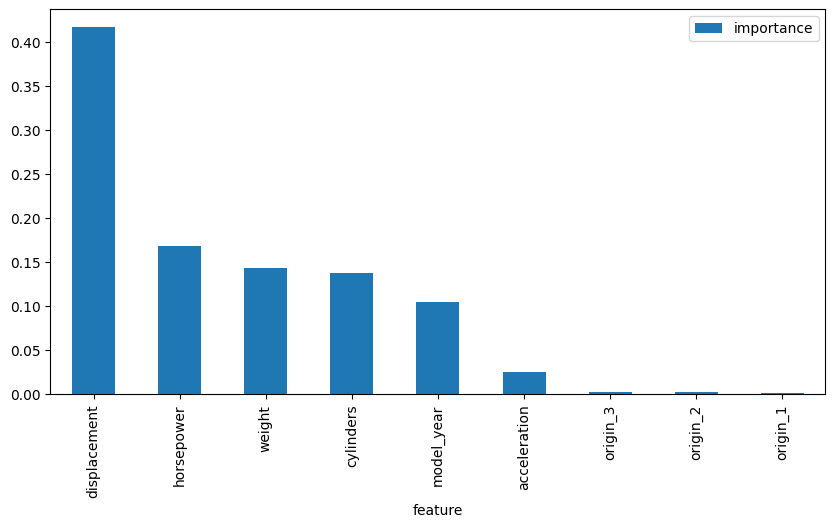

In [10]:
importance.plot(
  kind="bar",
  x="feature",
  y="importance",
  figsize=(10, 5)
)

In [11]:
rf_model = RandomForestRegressor(
  n_estimators=300,
  max_depth=5, # 기본값 None
  min_samples_leaf=3, # 기본값 1 / 마지막 노드에 최소 데이터 개수
  random_state=42
)

# 이전 모델
# rf_model = RandomForestRegressor(
#   n_estimators=100, # 결정 트리 100개를 만든다는 의미
#   random_state=42
# )

rf_model.fit(X_train, y_train)
pred = rf_model.predict(X_test)

print("train R2:", rf_model.score(X_train, y_train))
print("test R2:", rf_model.score(X_test, y_test))
print("MAE:", mean_absolute_error(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
print("R2:", r2_score(y_test, pred))

# 이전 수치
# 랜덤 포레스트 R2: 0.8858903470374668
# 랜덤 포레스트 MAE: 1.7398227848101262
# 랜덤 포레스트 RMSE: 2.4133427523885467

train R2: 0.9313395154781434
test R2: 0.8866269816632926
MAE: 1.7608238458264052
RMSE: 2.4055404755625096
R2: 0.8866269816632926


- train R2: 0.9313395154781434
- test R2: 0.8866269816632926

으로 과적합이 조금 나아진 편, 일반화 성능은 유지

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge

models = {
  "Linear Regression": LinearRegression(),
  "Ridge": Ridge(alpha=1.0, random_state=42),
  "Random Forest": RandomForestRegressor(
    n_estimators=300,
    max_depth=5, # 기본값 None
    min_samples_leaf=3, # 기본값 1 / 마지막 노드에 최소 데이터 개수
    random_state=42
  )
}

In [14]:
scores = []

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    scores.append({
        "model": name,
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "R2": r2_score(y_test, pred),
        "train_R2": model.score(X_train, y_train),
        "test_R2": model.score(X_test, y_test)
    })

score_df = pd.DataFrame(scores)
score_df

,model,MAE,RMSE,R2,train_R2,test_R2
0,Linear Regression,2.462000,3.256114,0.792277,0.828687,0.792277
1,Ridge,2.459298,3.253206,0.792648,0.828681,0.792648
2,Random Forest,1.760824,2.405540,0.886627,0.931340,0.886627


In [15]:
result = pd.DataFrame({
  "actual": y_test,
  "pred": pred,
  "error": y_test - pred,
  "abs_error": abs(y_test - pred,)
})

result.sort_values("abs_error", ascending=False).head(10)

,actual,pred,error,abs_error
111,18.0,27.259812,-9.259812,9.259812
394,44.0,37.307759,6.692241,6.692241
366,17.6,23.985686,-6.385686,6.385686
147,24.0,28.947913,-4.947913,4.947913
142,26.0,30.602036,-4.602036,4.602036
335,35.0,30.659265,4.340735,4.340735
30,28.0,23.834587,4.165413,4.165413
270,21.1,25.109971,-4.009971,4.009971
56,26.0,29.943089,-3.943089,3.943089
277,16.2,19.734551,-3.534551,3.534551


In [23]:
X_test.loc[111]

displacement     70.0
cylinders           3
horsepower       90.0
weight           2124
acceleration     13.5
model_year         73
origin_1        False
origin_2        False
origin_3         True
Name: 111, dtype: object

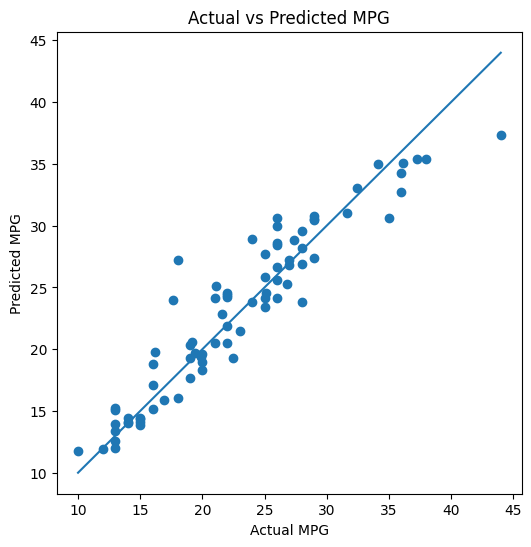

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(y_test, pred)
plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")
plt.title("Actual vs Predicted MPG")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.show()

In [26]:
from sklearn.tree import export_text

tree_text = export_text(
  rf_model.estimators_[0],
  feature_names=list(X.columns)
)

print(tree_text)

|--- displacement <= 198.50
|   |--- horsepower <= 70.50
|   |   |--- model_year <= 77.50
|   |   |   |--- horsepower <= 68.50
|   |   |   |   |--- acceleration <= 19.75
|   |   |   |   |   |--- value: [31.30]
|   |   |   |   |--- acceleration >  19.75
|   |   |   |   |   |--- value: [29.00]
|   |   |   |--- horsepower >  68.50
|   |   |   |   |--- value: [33.88]
|   |   |--- model_year >  77.50
|   |   |   |--- horsepower <= 66.00
|   |   |   |   |--- acceleration <= 16.30
|   |   |   |   |   |--- value: [34.79]
|   |   |   |   |--- acceleration >  16.30
|   |   |   |   |   |--- value: [38.16]
|   |   |   |--- horsepower >  66.00
|   |   |   |   |--- displacement <= 101.50
|   |   |   |   |   |--- value: [30.98]
|   |   |   |   |--- displacement >  101.50
|   |   |   |   |   |--- value: [34.21]
|   |--- horsepower >  70.50
|   |   |--- model_year <= 76.50
|   |   |   |--- acceleration <= 18.00
|   |   |   |   |--- weight <= 2750.50
|   |   |   |   |   |--- value: [24.35]
|   |   |   |

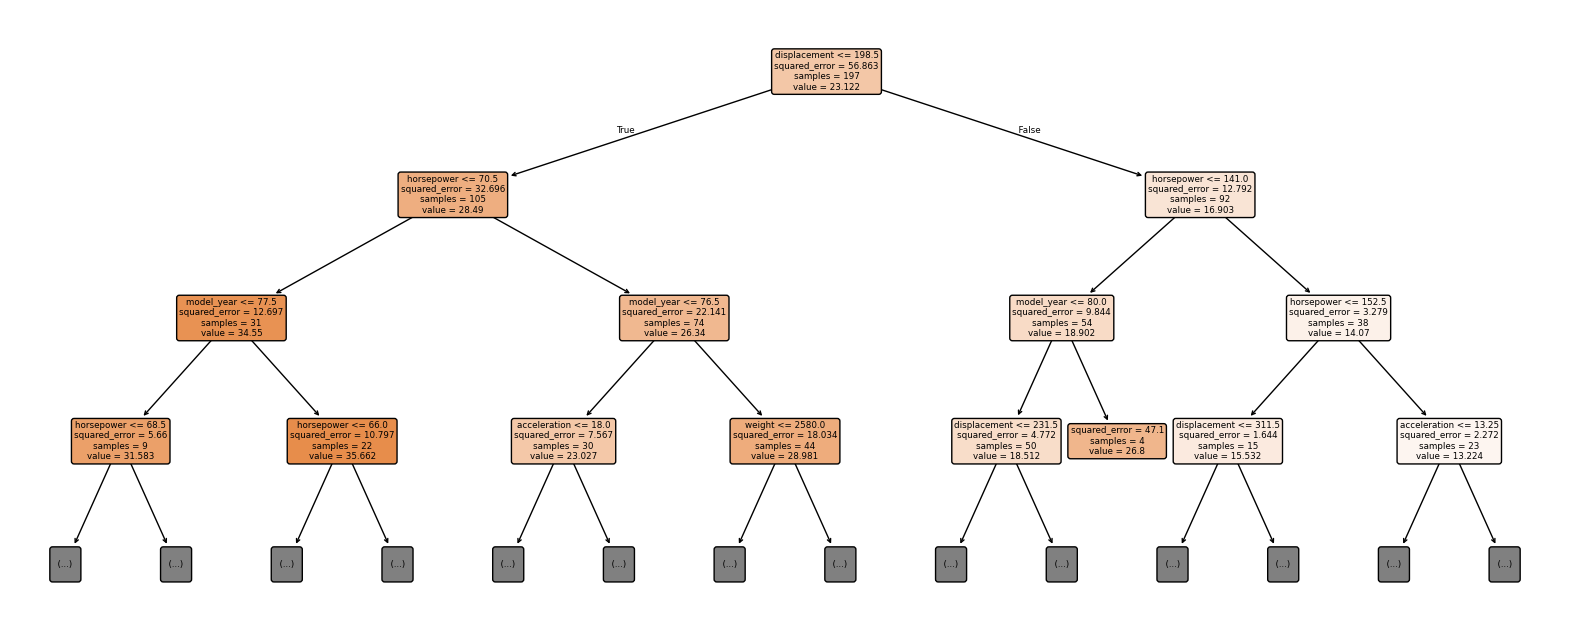

In [27]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 8))

plot_tree(
    rf_model.estimators_[0],
    feature_names=X.columns,
    filled=True,
    rounded=True,
    max_depth=3
)

plt.show()